# 07 — Mel-Spectrogram Pipeline for Deep Learning
## Converting Audio Signals to CNN-Ready Spectro-Temporal Images

---

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from collections import Counter

from src.utils import (
    set_plot_style, CLASS_LABELS, TARGET_SR,
    CLEANED_DIR, NOISY_DIR, AUDIO_EXTENSIONS, discover_audio_files
)
from src.dl_data import (
    audio_to_mel_spectrogram, pad_or_truncate_spectrogram,
    spec_augment, MEL_CONFIG, MAX_TIME_FRAMES, AUDIO_DURATION_SEC,
    discover_audio_for_dl, InfantCryDataset, create_data_loaders
)

set_plot_style()
print("Mel-Spectrogram Pipeline Ready")
print("Target SR:", TARGET_SR, "Hz | Mel bins:", MEL_CONFIG['n_mels'], "| Max frames:", MAX_TIME_FRAMES)

Mel-Spectrogram Pipeline Ready
Target SR: 16000 Hz | Mel bins: 128 | Max frames: 188


## 1. Audio Signal to Mel-Spectrogram Transformation

The pipeline converts raw 1D audio waveforms into 2D spectro-temporal representations:

1. **Raw Waveform** → 1D signal at 16kHz
2. **STFT** → Complex time-frequency representation
3. **Mel Filterbank** → Perceptually-scaled frequency axis
4. **Log Compression** → Dynamic range compression (dB scale)
5. **Normalization** → Zero-mean, unit-variance

Sample: 357c.wav | Label: belly_pain
Duration: 6.53s -> Fixed: 3.00s


/var/folders/q1/mvths70j0jx2jxq87_09nq8m0000gn/T/ipykernel_19570/556553352.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


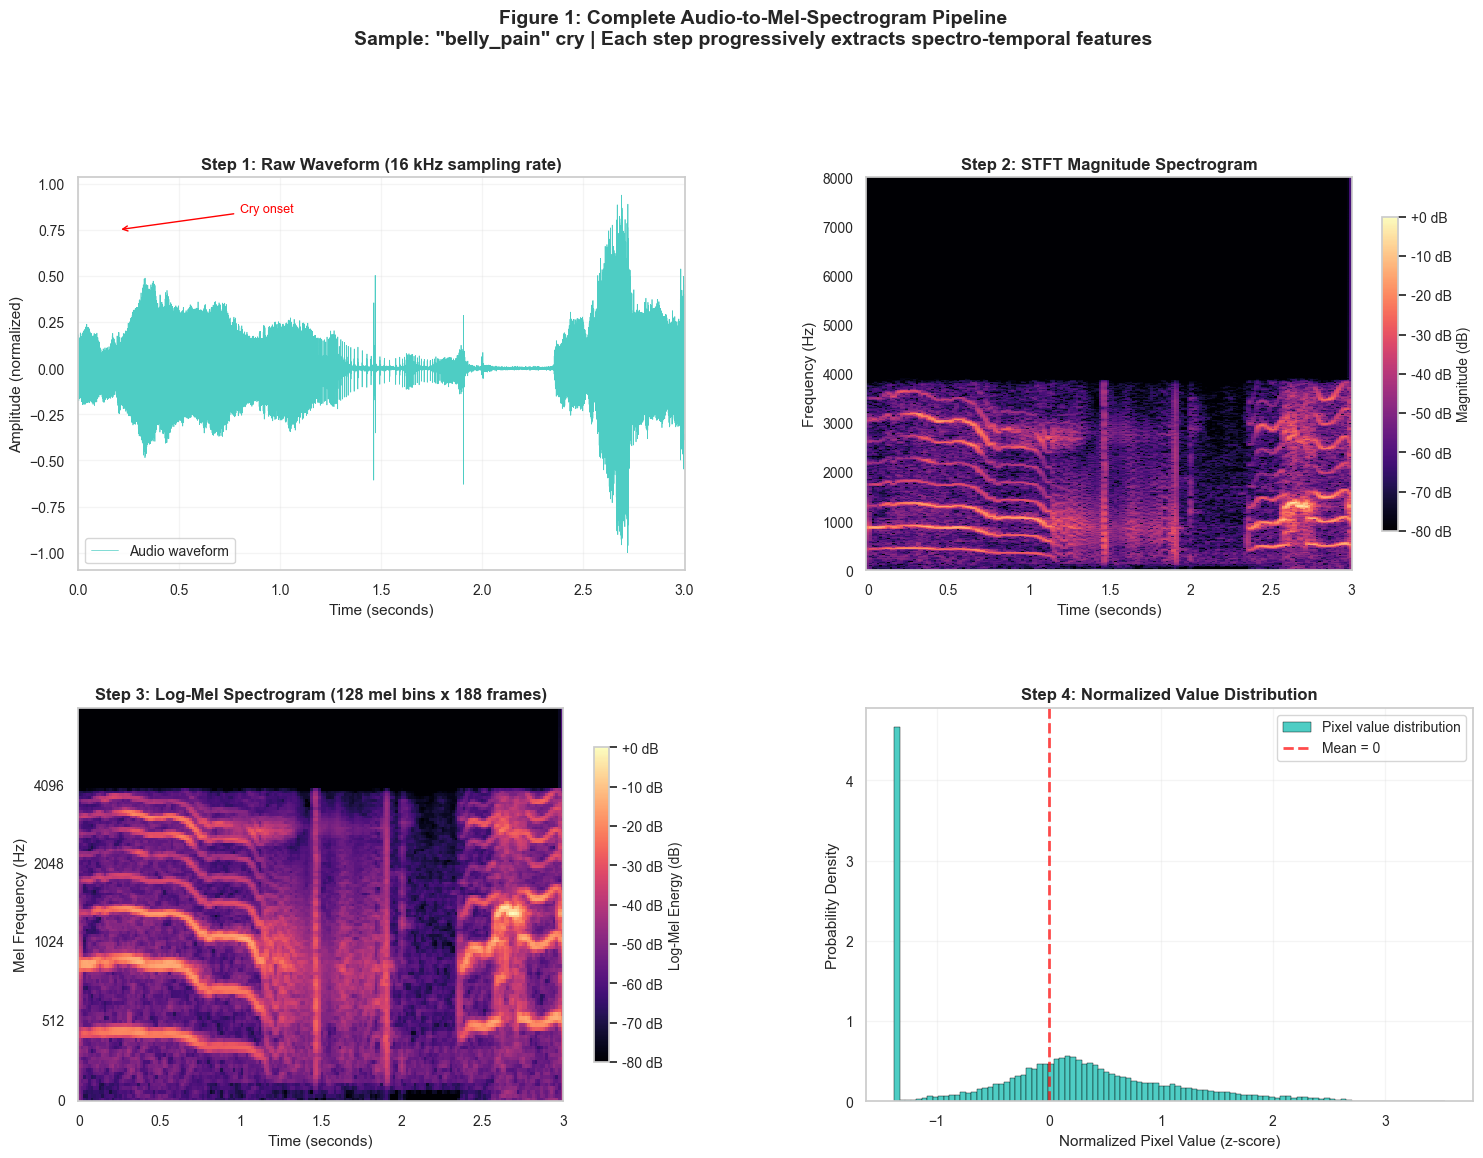

In [2]:
# ============================================================
# Figure 1: Complete Audio -> Mel-Spectrogram Pipeline
# ============================================================

sample_files = discover_audio_files(CLEANED_DIR)
sample_path, sample_label = sample_files[0]
y, sr = librosa.load(sample_path, sr=TARGET_SR)

target_len = int(TARGET_SR * AUDIO_DURATION_SEC)
if len(y) < target_len:
    y_fixed = np.pad(y, (0, target_len - len(y)), mode='constant')
else:
    y_fixed = y[:target_len]

print("Sample:", os.path.basename(sample_path), "| Label:", sample_label)
print("Duration: {:.2f}s -> Fixed: {:.2f}s".format(len(y)/sr, len(y_fixed)/sr))

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Step 1: Raw Waveform
ax1 = fig.add_subplot(gs[0, 0])
time_axis = np.arange(len(y_fixed)) / sr
ax1.plot(time_axis, y_fixed, color='#4ECDC4', linewidth=0.5, label="Audio waveform")
ax1.set_title('Step 1: Raw Waveform (16 kHz sampling rate)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (seconds)', fontsize=11)
ax1.set_ylabel('Amplitude (normalized)', fontsize=11)
ax1.set_xlim(0, AUDIO_DURATION_SEC)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.2)
ax1.annotate("Cry onset", xy=(0.2, max(y_fixed)*0.8), fontsize=9, color="red",
             arrowprops=dict(arrowstyle="->", color="red"), xytext=(0.8, max(y_fixed)*0.9))

# Step 2: STFT Spectrogram
ax2 = fig.add_subplot(gs[0, 1])
D = librosa.stft(y_fixed, n_fft=MEL_CONFIG['n_fft'], hop_length=MEL_CONFIG['hop_length'])
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img2 = librosa.display.specshow(D_db, sr=sr, hop_length=MEL_CONFIG['hop_length'],
                                 x_axis='time', y_axis='hz', ax=ax2, cmap='magma')
ax2.set_title('Step 2: STFT Magnitude Spectrogram', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_ylabel('Frequency (Hz)', fontsize=11)
ax2.set_ylim(0, 8000)
cbar2 = plt.colorbar(img2, ax=ax2, format='%+2.0f dB', shrink=0.8)
cbar2.set_label('Magnitude (dB)', fontsize=10)

# Step 3: Log-Mel Spectrogram
ax3 = fig.add_subplot(gs[1, 0])
mel_spec = audio_to_mel_spectrogram(y_fixed, sr=sr)
mel_spec_fixed = pad_or_truncate_spectrogram(mel_spec)
img3 = librosa.display.specshow(mel_spec_fixed, sr=sr, hop_length=MEL_CONFIG['hop_length'],
                                 x_axis='time', y_axis='mel', ax=ax3, cmap='magma',
                                 fmax=MEL_CONFIG['fmax'])
ax3.set_title('Step 3: Log-Mel Spectrogram (128 mel bins x {} frames)'.format(MAX_TIME_FRAMES),
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Time (seconds)', fontsize=11)
ax3.set_ylabel('Mel Frequency (Hz)', fontsize=11)
cbar3 = plt.colorbar(img3, ax=ax3, format='%+2.0f dB', shrink=0.8)
cbar3.set_label('Log-Mel Energy (dB)', fontsize=10)

# Step 4: Normalized Distribution
ax4 = fig.add_subplot(gs[1, 1])
mel_norm = (mel_spec_fixed - mel_spec_fixed.mean()) / (mel_spec_fixed.std() + 1e-8)
ax4.hist(mel_norm.flatten(), bins=100, color='#4ECDC4', edgecolor='black', linewidth=0.3,
         density=True, label="Pixel value distribution")
ax4.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Mean = 0')
ax4.set_title('Step 4: Normalized Value Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Normalized Pixel Value (z-score)', fontsize=11)
ax4.set_ylabel('Probability Density', fontsize=11)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.2)

plt.suptitle('Figure 1: Complete Audio-to-Mel-Spectrogram Pipeline\n'
             'Sample: "{}" cry | Each step progressively extracts spectro-temporal features'.format(sample_label),
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. Per-Class Mel-Spectrogram Comparison

Each cry type produces distinct spectro-temporal patterns that the CNN must learn to distinguish.

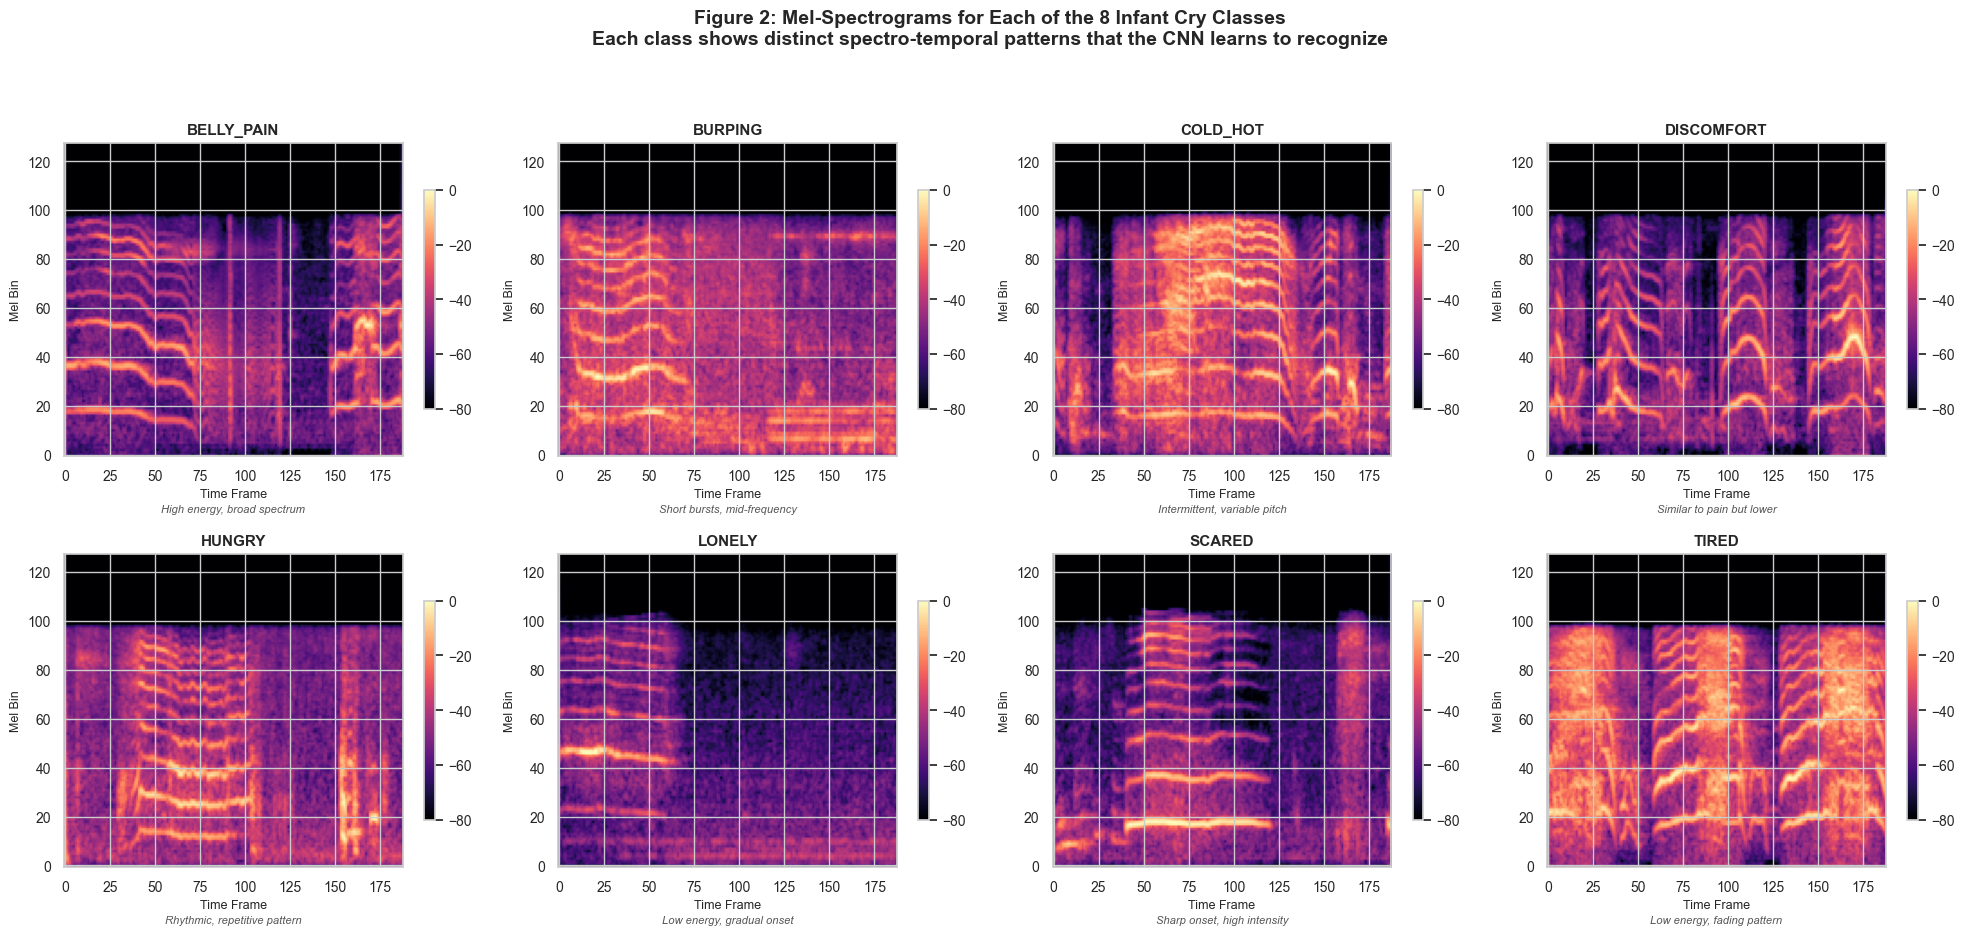

In [3]:
# ============================================================
# Figure 2: Mel-Spectrograms for All 8 Cry Classes
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

sample_files = discover_audio_files(CLEANED_DIR)
class_samples = {}
for fpath, label in sample_files:
    if label not in class_samples:
        class_samples[label] = fpath

observations = {
    'belly_pain': 'High energy, broad spectrum',
    'burping': 'Short bursts, mid-frequency',
    'cold_hot': 'Intermittent, variable pitch',
    'discomfort': 'Similar to pain but lower',
    'hungry': 'Rhythmic, repetitive pattern',
    'lonely': 'Low energy, gradual onset',
    'scared': 'Sharp onset, high intensity',
    'tired': 'Low energy, fading pattern',
}

for idx, (label, ax) in enumerate(zip(CLASS_LABELS, axes.flat)):
    if label in class_samples:
        y_tmp, _ = librosa.load(class_samples[label], sr=TARGET_SR, duration=AUDIO_DURATION_SEC)
        target_len = int(TARGET_SR * AUDIO_DURATION_SEC)
        if len(y_tmp) < target_len:
            y_tmp = np.pad(y_tmp, (0, target_len - len(y_tmp)), mode='constant')
        mel = audio_to_mel_spectrogram(y_tmp, sr=TARGET_SR)
        mel = pad_or_truncate_spectrogram(mel)
        img = ax.imshow(mel, aspect='auto', origin='lower', cmap='magma')
        plt.colorbar(img, ax=ax, shrink=0.7)
    
    obs = observations.get(label, '')
    ax.set_title(label.upper(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Time Frame', fontsize=9)
    ax.set_ylabel('Mel Bin', fontsize=9)
    # Add observation text
    ax.text(0.5, -0.18, obs, transform=ax.transAxes, fontsize=8,
            ha='center', fontstyle='italic', color='#555')

plt.suptitle('Figure 2: Mel-Spectrograms for Each of the 8 Infant Cry Classes\n'
             'Each class shows distinct spectro-temporal patterns that the CNN learns to recognize',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

## 3. SpecAugment — Data Augmentation for Audio

SpecAugment (Park et al., 2019) masks random portions of the spectrogram:
- **Frequency Masking**: Forces model to not rely on any single frequency band
- **Time Masking**: Forces model to classify from partial temporal context

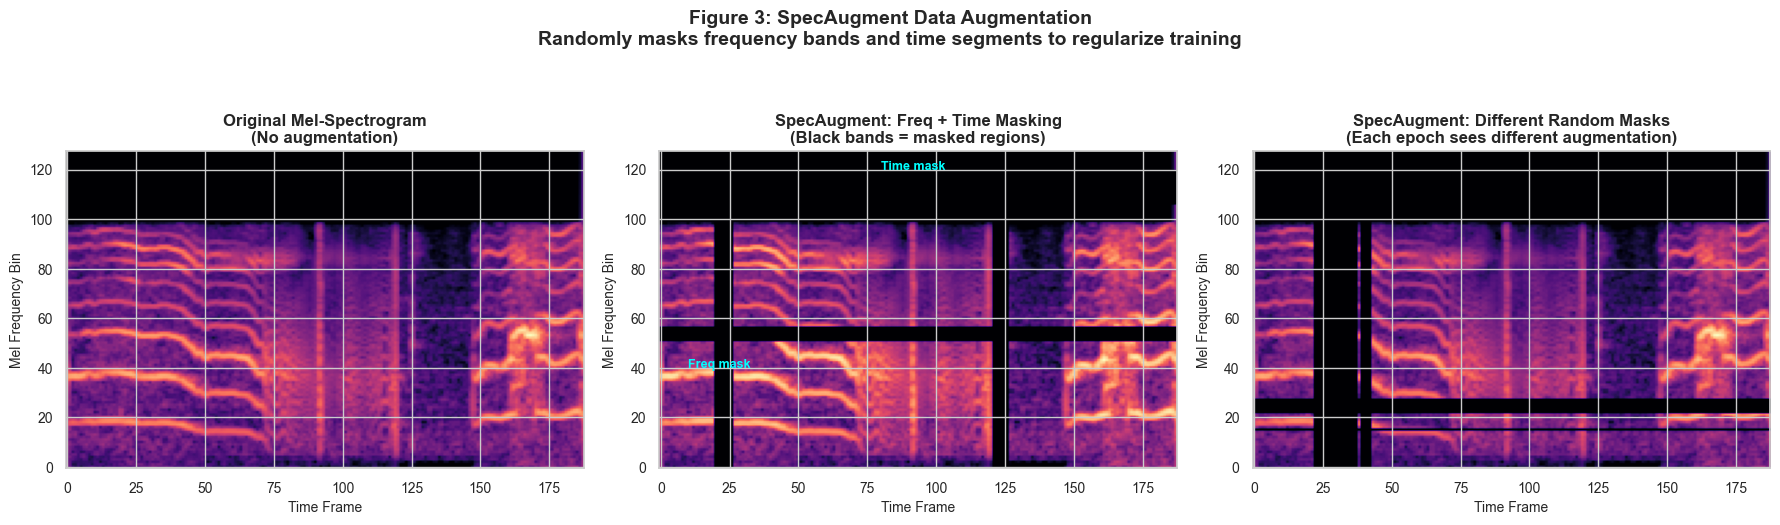

SpecAugment acts as implicit regularization: each training epoch sees different masks


In [4]:
# ============================================================
# Figure 3: SpecAugment Visualization
# ============================================================

# Get a clean spectrogram
first_label = list(class_samples.keys())[0]
y_demo, _ = librosa.load(class_samples[first_label], sr=TARGET_SR, duration=AUDIO_DURATION_SEC)
target_len = int(TARGET_SR * AUDIO_DURATION_SEC)
if len(y_demo) < target_len:
    y_demo = np.pad(y_demo, (0, target_len - len(y_demo)), mode='constant')
mel_demo = audio_to_mel_spectrogram(y_demo, sr=TARGET_SR)
mel_demo = pad_or_truncate_spectrogram(mel_demo)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original
axes[0].imshow(mel_demo, aspect='auto', origin='lower', cmap='magma')
axes[0].set_title('Original Mel-Spectrogram\n(No augmentation)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Frame', fontsize=10)
axes[0].set_ylabel('Mel Frequency Bin', fontsize=10)

# SpecAugment #1
np.random.seed(42)
aug1 = spec_augment(mel_demo, freq_mask_param=20, time_mask_param=25, n_freq_masks=2, n_time_masks=2)
axes[1].imshow(aug1, aspect='auto', origin='lower', cmap='magma')
axes[1].set_title('SpecAugment: Freq + Time Masking\n(Black bands = masked regions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Frame', fontsize=10)
axes[1].set_ylabel('Mel Frequency Bin', fontsize=10)
# Label masks
axes[1].annotate('Freq mask', xy=(10, 40), fontsize=9, color='cyan', fontweight='bold')
axes[1].annotate('Time mask', xy=(80, 120), fontsize=9, color='cyan', fontweight='bold')

# SpecAugment #2
np.random.seed(17)
aug2 = spec_augment(mel_demo, freq_mask_param=15, time_mask_param=25, n_freq_masks=2, n_time_masks=2)
axes[2].imshow(aug2, aspect='auto', origin='lower', cmap='magma')
axes[2].set_title('SpecAugment: Different Random Masks\n(Each epoch sees different augmentation)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time Frame', fontsize=10)
axes[2].set_ylabel('Mel Frequency Bin', fontsize=10)

plt.suptitle('Figure 3: SpecAugment Data Augmentation\n'
             'Randomly masks frequency bands and time segments to regularize training',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("SpecAugment acts as implicit regularization: each training epoch sees different masks")

## 4. Dataset Preparation and DataLoader Verification

Total audio files discovered: 2108
Number of classes: 8
Label names: ['belly_pain', 'burping', 'cold_hot', 'discomfort', 'hungry', 'lonely', 'scared', 'tired']

Class distribution:
  belly_pain     :  254 ( 12.0%) ############
  burping        :  236 ( 11.2%) ###########
  cold_hot       :  230 ( 10.9%) ##########
  discomfort     :  276 ( 13.1%) #############
  hungry         :  764 ( 36.2%) ####################################
  lonely         :   22 (  1.0%) #
  scared         :   54 (  2.6%) ##
  tired          :  272 ( 12.9%) ############

Train/Val split: 1686 / 422



Batch tensor shape: torch.Size([32, 1, 128, 188]) (Batch, Channels, MelBins, TimeFrames)
Value range: [-1.99, 5.88]


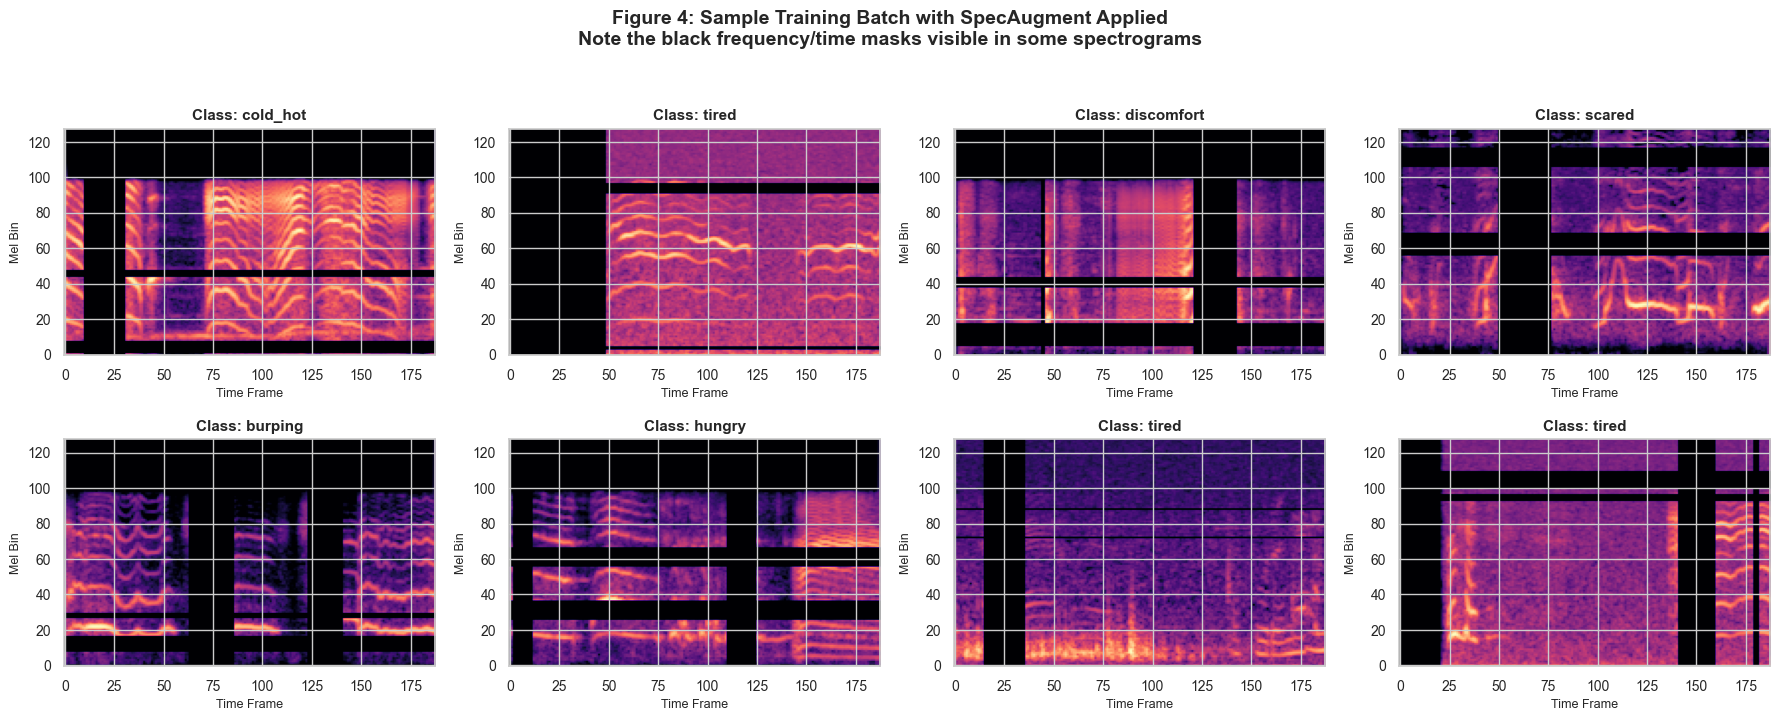


Mel-Spectrogram Pipeline Complete!
Next: 08_architecture_from_scratch.ipynb


In [5]:
# ============================================================
# Figure 4: Class Distribution & Sample Batch
# ============================================================
from sklearn.model_selection import train_test_split

file_paths, labels, label_names = discover_audio_for_dl([CLEANED_DIR, NOISY_DIR])
print("Total audio files discovered:", len(file_paths))
print("Number of classes:", len(label_names))
print("Label names:", label_names)

class_counts = Counter(labels)
print("\nClass distribution:")
for idx, name in enumerate(label_names):
    count = class_counts.get(idx, 0)
    pct = count / len(labels) * 100
    bar = '#' * int(pct)
    print("  {:15s}: {:4d} ({:5.1f}%) {}".format(name, count, pct, bar))

train_paths, val_paths, train_labels, val_labels = train_test_split(
    file_paths, labels, test_size=0.2, random_state=42, stratify=labels
)
print("\nTrain/Val split: {} / {}".format(len(train_paths), len(val_paths)))

train_loader, val_loader, train_dataset, val_dataset = create_data_loaders(
    train_paths, train_labels, val_paths, val_labels,
    class_names=label_names, batch_size=32, num_workers=0
)

batch_x, batch_y = next(iter(train_loader))
print("\nBatch tensor shape:", batch_x.shape, "(Batch, Channels, MelBins, TimeFrames)")
print("Value range: [{:.2f}, {:.2f}]".format(batch_x.min().item(), batch_x.max().item()))

# Visualize batch
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, ax in enumerate(axes.flat):
    if i < len(batch_x):
        ax.imshow(batch_x[i, 0].numpy(), aspect='auto', origin='lower', cmap='magma')
        label_idx = batch_y[i].item()
        ax.set_title("Class: " + label_names[label_idx], fontsize=11, fontweight='bold')
        ax.set_xlabel('Time Frame', fontsize=9)
        ax.set_ylabel('Mel Bin', fontsize=9)
    else:
        ax.axis('off')

plt.suptitle('Figure 4: Sample Training Batch with SpecAugment Applied\n'
             'Note the black frequency/time masks visible in some spectrograms',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("\nMel-Spectrogram Pipeline Complete!")
print("Next: 08_architecture_from_scratch.ipynb")